# 01. Training and fine-tuning: per-epoch curves and test errors

This notebook shows the learning curves and final errors of every CHGNet and MACE training run in
this repository. Nothing is retrained here: all numbers are parsed from the original training logs by
`scripts/parse_training_logs.py` into `results/training_runs.json`.

* **CHGNet** (pretrained CHGNet v0.3.0, 412,525 parameters, all layers trainable): per-epoch training
  averages and validation MAE from the trainer output; test MAE from the final `**` line.
  Energies in eV/atom, forces in eV/Å, printed by CHGNet with three decimals.
* **MACE** (MACE 0.3.12): per-epoch validation metrics from `*_train.txt`; the training loss is the mean
  batch loss of each epoch. Final train/valid/test tables are copied as printed (meV/atom, meV/Å).

All train/validation/test splits are random frame-level splits of correlated AIMD trajectories
(except the Na-oxide CHGNet runs, which hold out a full temperature block), so test errors measure
interpolation within the sampled temperature range.

In [1]:
import json
import numpy as np
import pandas as pd
from plot_style import plt, save

runs = json.load(open("../results/training_runs.json"))["runs"]
by_study = {}
for r in runs:
    by_study.setdefault(r["study"], []).append(r)
{k: len(v) for k, v in by_study.items()}

{'chgnet_lyc_data_size': 3,
 'chgnet_lyc_epochs': 2,
 'chgnet_lyc_histogram': 4,
 'chgnet_lyc_batch_size': 4,
 'chgnet_na_oxides': 2,
 'mace_lyc': 2,
 'mace_20258': 2,
 'mace_45802': 2,
 'mace_75421': 2,
 'mace_na2o_neb_strategies': 17}

## 1. CHGNet fine-tuning on Li–Y–Cl AIMD (Li<sub>15</sub>Y<sub>7</sub>Cl<sub>36</sub>, 58 atoms)

Training data: 399,000 AIMD frames (500–900 K, 2 fs), energies shifted by the MP2020 Cl anion
correction. Two ways of choosing the training frames were compared:

* **Contiguous subsets** (folder names `N_itteration`): the first 7,980 / 15,960 / 30,693 rows of the
  frame table. Because the table starts with the 900 K block, these subsets contain 900 K frames only.
* **Energy-histogram sampling**: total energies of all 399,000 frames are binned (60 bins) and an equal
  quota is drawn from each bin, so rare high- and low-energy configurations are kept.

Solid lines: validation MAE; dashed: training average over the epoch.

'figures/training/chgnet_lyc_force_mae_vs_epoch.png'

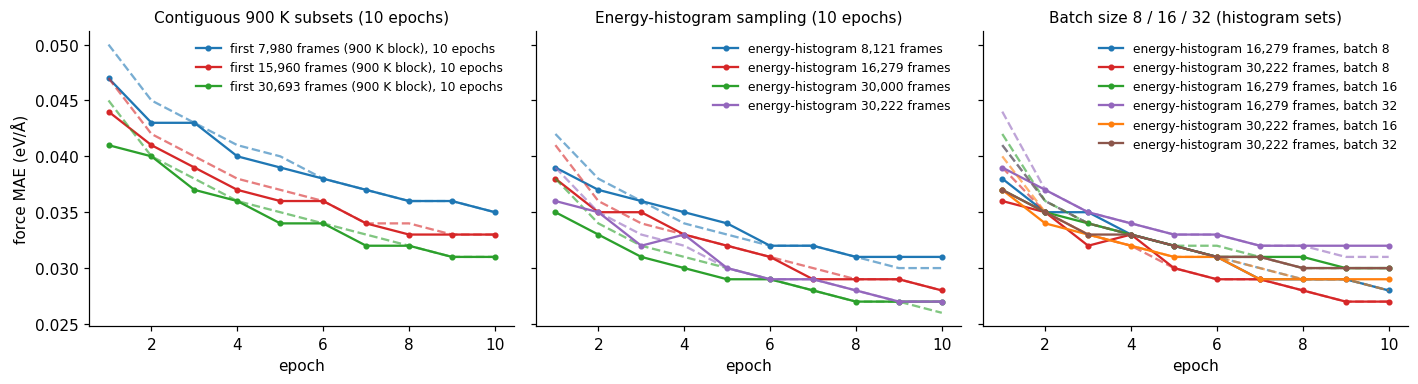

In [2]:
def chgnet_curves(ax, run, key, color, label):
    tr = run["train_epoch_avg"]; va = run["val_per_epoch"]
    ax.plot([d["epoch"] + 1 for d in va], [d[key] for d in va], "-o", ms=3, color=color, label=label)
    ax.plot([d["epoch"] + 1 for d in tr], [d[key] for d in tr], "--", color=color, alpha=0.6)

groups = [("chgnet_lyc_data_size", "Contiguous 900 K subsets (10 epochs)"),
          ("chgnet_lyc_histogram", "Energy-histogram sampling (10 epochs)"),
          ("chgnet_lyc_batch_size", "Batch size 8 / 16 / 32 (histogram sets)")]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
baseline = {r["label"]: r for r in by_study["chgnet_lyc_histogram"]}
for ax, (study, title) in zip(axes, groups):
    group = list(by_study[study])
    if study == "chgnet_lyc_batch_size":  # add the batch-8 runs of the same two training sets
        group = [baseline["energy-histogram 16,279 frames"], baseline["energy-histogram 30,222 frames"]] + group
    for i, r in enumerate(group):
        label = r["label"] + (", batch 8" if study == "chgnet_lyc_batch_size" and "batch" not in r["label"] else "")
        chgnet_curves(ax, r, "f_mae", f"C{i}", label)
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend(frameon=False)
axes[0].set_ylabel("force MAE (eV/Å)")
fig.tight_layout(); save(fig, "training/chgnet_lyc_force_mae_vs_epoch")

'figures/training/chgnet_lyc_long_training.png'

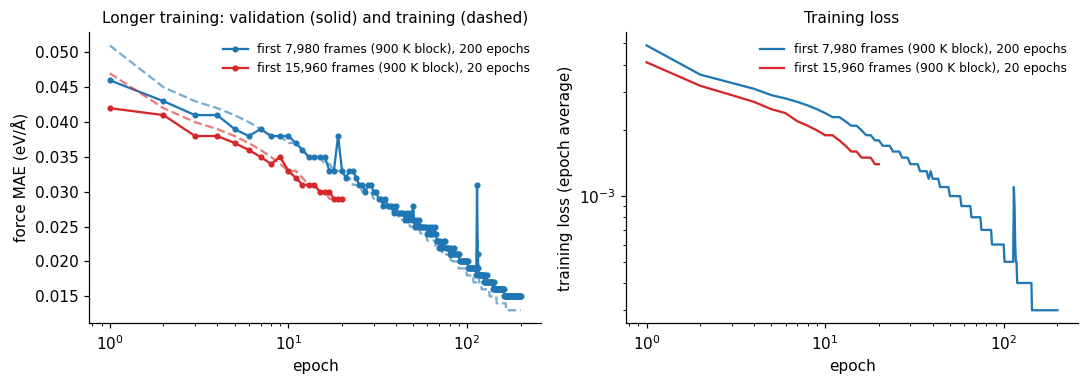

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for i, r in enumerate(by_study["chgnet_lyc_epochs"]):
    chgnet_curves(axes[0], r, "f_mae", f"C{i}", r["label"])
    axes[1].plot([d["epoch"] + 1 for d in r["train_epoch_avg"]], [d["loss"] for d in r["train_epoch_avg"]],
                 color=f"C{i}", label=r["label"])
axes[0].set_xscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("force MAE (eV/Å)")
axes[0].set_title("Longer training: validation (solid) and training (dashed)"); axes[0].legend(frameon=False)
axes[1].set_xscale("log"); axes[1].set_yscale("log"); axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training loss (epoch average)"); axes[1].set_title("Training loss"); axes[1].legend(frameon=False)
fig.tight_layout(); save(fig, "training/chgnet_lyc_long_training")

In [4]:
def chgnet_table(studies):
    rows = []
    for s in studies:
        for r in by_study[s]:
            rows.append({"run": r["label"], "frames": r.get("n_frames"), "epochs": r.get("epochs"),
                         "batch": r.get("batch"),
                         "val force MAE (last epoch)": r["val_per_epoch"][-1]["f_mae"],
                         "test energy MAE (eV/atom)": r["test"]["e_mae"],
                         "test force MAE (eV/Å)": r["test"]["f_mae"]})
    return pd.DataFrame(rows)

chgnet_table(["chgnet_lyc_data_size", "chgnet_lyc_epochs", "chgnet_lyc_histogram", "chgnet_lyc_batch_size"])

,run,frames,epochs,batch,val force MAE (last epoch),test energy MAE (eV/atom),test force MAE (eV/Å)
0,"first 7,980 frames (900 K block), 10 epochs",7980,10,8,0.035,0.001,0.036
1,"first 15,960 frames (900 K block), 10 epochs",15960,10,8,0.033,0.001,0.033
2,"first 30,693 frames (900 K block), 10 epochs",30693,10,8,0.031,0.001,0.032
3,"first 7,980 frames (900 K block), 200 epochs",7980,200,8,0.015,0.001,0.015
4,"first 15,960 frames (900 K block), 20 epochs",15960,20,8,0.029,0.001,0.029
5,"energy-histogram 8,121 frames",8121,10,8,0.031,0.001,0.031
6,"energy-histogram 16,279 frames",16279,10,8,0.028,0.001,0.029
7,"energy-histogram 30,000 frames",30000,10,8,0.027,0.001,0.026
8,"energy-histogram 30,222 frames",30222,10,8,0.027,0.001,0.027
9,"energy-histogram 16,279 frames, batch 16",16279,10,16,0.030,0.001,0.030


**Reading the table.** At equal data size and 10 epochs, the energy-histogram sets reach lower test
force MAE (0.026–0.031 eV/Å) than the contiguous 900 K subsets (0.032–0.036 eV/Å), but the two test
sets are drawn from different frame pools (all temperatures vs 900 K only), so this comparison is
indicative only. Training 7,980 frames for 200 epochs instead of 10 lowers the test force MAE from
0.036 to 0.015 eV/Å. Batch size (8/16/32) changes the result by at most 0.003 eV/Å.

## 2. CHGNet fine-tuning on Na-ion oxide conductors, held-out temperature

NTPO (Na<sub>8</sub>Ti<sub>8</sub>P<sub>8</sub>O<sub>40</sub>, 64 atoms) and NSGO
(Na<sub>12</sub>Ge<sub>12</sub>Sb<sub>16</sub>P<sub>4</sub>O<sub>80</sub>, 124 atoms): 25,000 AIMD frames
each, MP2020 oxide correction applied. The first 5,000 frames (the 1150 K block) are the **test set**
and are never seen in training, so this test measures transfer to an unseen temperature.

,run,frames,epochs,batch,val force MAE (last epoch),test energy MAE (eV/atom),test force MAE (eV/Å)
0,"NTPO (Na8Ti8P8O40), 1150 K block held out",None,10,32,0.035,0.001,0.035
1,"NSGO (Na12Ge12Sb16P4O80), 1150 K block held out",None,10,32,0.039,0.001,0.040


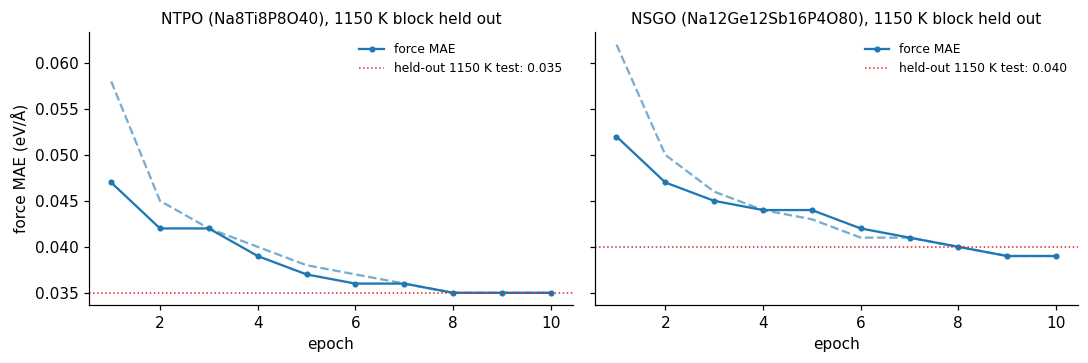

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, r in zip(axes, by_study["chgnet_na_oxides"]):
    chgnet_curves(ax, r, "f_mae", "C0", "force MAE")
    ax.axhline(r["test"]["f_mae"], color="C1", lw=1, ls=":", label=f"held-out 1150 K test: {r['test']['f_mae']:.3f}")
    ax.set_title(r["label"]); ax.set_xlabel("epoch"); ax.legend(frameon=False)
axes[0].set_ylabel("force MAE (eV/Å)")
fig.tight_layout(); save(fig, "training/chgnet_na_oxides_force_mae_vs_epoch")
chgnet_table(["chgnet_na_oxides"])

## 3. MACE: trained from scratch vs fine-tuned from MACE-MPA-0

Four materials: Li<sub>15</sub>Y<sub>7</sub>Cl<sub>36</sub> (LYC) and three Na-ion oxide conductors
(20258: Na<sub>9</sub>Y<sub>6</sub>Si<sub>3</sub>P<sub>9</sub>O<sub>42</sub>; 45802:
Na<sub>5</sub>Nb<sub>5</sub>W<sub>11</sub>O<sub>48</sub>; 75421:
Na<sub>11</sub>Si<sub>11</sub>Sb<sub>16</sub>As<sub>5</sub>O<sub>80</sub>), each trained on its own AIMD
data (800–1300 K for the Na conductors), energies and forces only.

* **From scratch**: 128x0e+128x1o, 2 interactions, correlation 3, r<sub>max</sub> = 5 Å, max_ell 3,
  batch 8, 10 epochs, E/F weights 100/1000, EMA + SWA (≈945k parameters).
* **Fine-tuned**: MACE-MPA-0 (medium) foundation model, same data and epochs.

The per-epoch validation metrics below are computed the same way for every run (both MAE and RMSE are
logged), so scratch and fine-tuned models can be compared directly.

'figures/training/mace_scratch_vs_finetuned.png'

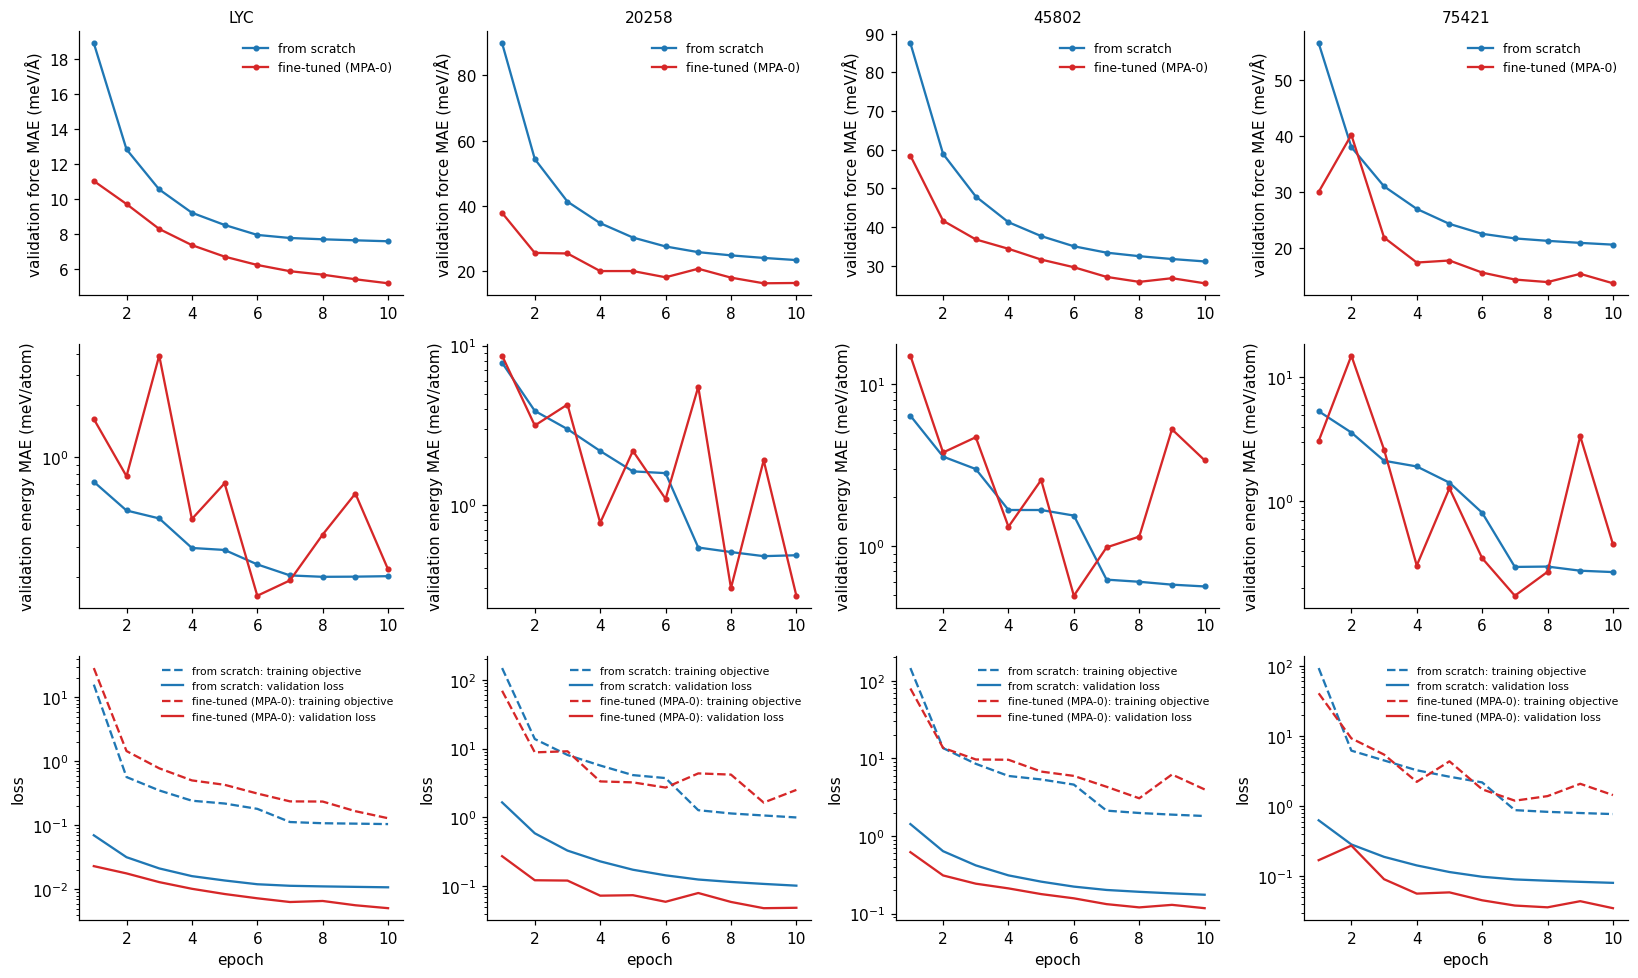

In [6]:
mace_studies = ["mace_lyc", "mace_20258", "mace_45802", "mace_75421"]
titles = {"mace_lyc": "LYC", "mace_20258": "20258", "mace_45802": "45802", "mace_75421": "75421"}
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for j, s in enumerate(mace_studies):
    for i, r in enumerate(by_study[s]):
        ev = [d for d in r["val_per_epoch"] if d["epoch"] is not None]
        kind = "fine-tuned (MPA-0)" if "fine-tuned" in r["label"] else "from scratch"
        axes[0, j].plot([d["epoch"] + 1 for d in ev], [1000 * d["mae_f"] for d in ev], "-o", ms=3, color=f"C{i}", label=kind)
        axes[1, j].plot([d["epoch"] + 1 for d in ev], [1000 * d["mae_e_per_atom"] for d in ev], "-o", ms=3, color=f"C{i}", label=kind)
        axes[2, j].plot([d["epoch"] + 1 for d in r["train_loss_epoch_mean"]], [d["loss"] for d in r["train_loss_epoch_mean"]],
                        "--", color=f"C{i}", label=f"{kind}: training objective")
        axes[2, j].plot([d["epoch"] + 1 for d in ev], [d["loss"] for d in ev], "-", color=f"C{i}", label=f"{kind}: validation loss")
    axes[0, j].set_title(titles[s]); axes[0, j].set_ylabel("validation force MAE (meV/Å)")
    axes[1, j].set_ylabel("validation energy MAE (meV/atom)"); axes[1, j].set_yscale("log")
    axes[2, j].set_yscale("log"); axes[2, j].set_ylabel("loss"); axes[2, j].set_xlabel("epoch")
    axes[0, j].legend(frameon=False); axes[2, j].legend(frameon=False, fontsize=7)
fig.tight_layout(); save(fig, "training/mace_scratch_vs_finetuned")

In [7]:
rows = []
for s in mace_studies:
    for r in by_study[s]:
        last = [d for d in r["val_per_epoch"] if d["epoch"] is not None][-1]
        first = r["val_per_epoch"][0]
        test = r["final_error_tables"]["test"][0]
        metric = "MAE" if any(k.startswith("MAE") for k in test) else "RMSE"
        rows.append({"material": titles[s], "model": r["label"].split(" ", 1)[1],
                     "valid F MAE at initialization (meV/Å)": round(1000 * first["mae_f"], 1) if first["epoch"] is None else None,
                     "valid F MAE, last epoch (meV/Å)": round(1000 * last["mae_f"], 1),
                     "valid F RMSE, last epoch (meV/Å)": round(1000 * last["rmse_f"], 1),
                     "valid E MAE, last epoch (meV/atom)": round(1000 * last["mae_e_per_atom"], 2),
                     f"final test table metric": metric,
                     "test E (meV/atom)": test.get(f"{metric} E / meV / atom"),
                     "test F (meV/Å)": test.get(f"{metric} F / meV / A")})
pd.DataFrame(rows)

,material,model,valid F MAE at initialization (meV/Å),"valid F MAE, last epoch (meV/Å)","valid F RMSE, last epoch (meV/Å)","valid E MAE, last epoch (meV/atom)",final test table metric,test E (meV/atom),test F (meV/Å)
0,LYC,from scratch,361.9,7.6,10.3,0.20,RMSE,0.3,10.3
1,LYC,fine-tuned from MACE-MPA-0,47.7,5.2,7.1,0.22,MAE,0.2,5.2
2,20258,from scratch,1017.5,23.3,31.6,0.48,RMSE,0.5,31.1
3,20258,fine-tuned from MACE-MPA-0,61.4,16.2,21.9,0.27,MAE,1.9,15.9
4,45802,from scratch,910.6,31.1,41.6,0.56,RMSE,0.7,42.4
5,45802,fine-tuned from MACE-MPA-0,355.4,25.4,34.0,3.39,MAE,3.4,26.0
6,75421,from scratch,982.5,20.5,28.0,0.27,RMSE,0.3,27.4
7,75421,fine-tuned from MACE-MPA-0,69.9,13.6,18.4,0.45,MAE,0.4,13.6


**Reading the table.** The per-epoch columns use the same metric for every run. The last three columns
are the final error tables exactly as MACE printed them: fine-tuned runs used `--error_table=PerAtomMAE`
(MAE) and from-scratch runs the default (RMSE), so compare the per-epoch columns, not the last two,
across model types. "valid F MAE at initialization" is the first evaluation in the log, made before
any optimizer step: for fine-tuned runs this is the foundation model after MACE has set the new
reference energies (E0s) and force scaling, for from-scratch runs it is the randomly initialized model.

**Loss panels.** The dashed line is the mean of the batch losses during each epoch (raw weights, still
changing within the epoch); the solid line is the validation loss computed after the epoch with the EMA
weights. They are logged differently, so compare their trends, not their magnitudes.

## 4. Parity plots: model vs DFT on the training, validation and test frames

Each saved model was evaluated (inference only, `scripts/parity_predictions.py`) on exactly the frames
it was trained, validated and tested on. As a check, the test MAE recomputed from these predictions is
compared with the value printed in the original training log. Force panels show individual Cartesian
components (subsampled to at most 300,000 per split); errors in the panels are in meV/atom and meV/Å.
For CHGNet, the models used for MD are the checkpoints with the lowest validation energy error
(`bestE`); when that is not the last epoch (200-epoch run: epoch 197) the recomputed test error differs
slightly from the log, which reports the final-epoch model.

In [8]:
import os
STYLE = {"train": dict(c="#d62728", marker="x", s=10, lw=0.6, label="train"),
         "valid": dict(c="#1f77b4", marker="+", s=14, lw=0.6, label="validation"),
         "test": dict(c="0.45", marker="o", s=8, lw=0, label="test")}

def parity(ax, P, kind, scale, unit):
    lo, hi = np.inf, -np.inf
    lines = []
    for split in ("train", "valid", "test"):
        if f"{split}_{kind}_ref" not in P:
            continue
        r, q = P[f"{split}_{kind}_ref"] * scale, P[f"{split}_{kind}_pred"] * scale
        ax.scatter(r, q, alpha=0.5, rasterized=True, **STYLE[split])
        lo, hi = min(lo, r.min(), q.min()), max(hi, r.max(), q.max())
        err = 1000 * (q - r)  # shown in meV/atom or meV/A
        lines.append(f"{STYLE[split]['label']}: MAE {np.mean(np.abs(err)):.1f}, RMSE {np.sqrt(np.mean(err ** 2)):.1f}")
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.text(0.03, 0.97, "\n".join(lines) + f"  (m{unit})", transform=ax.transAxes, va="top", fontsize=8)
    ax.legend(frameon=False, loc="lower right", fontsize=7, markerscale=1.5)

def load_parity(key):
    path = f"../results/parity/{key}.npz"
    return dict(np.load(path)) if os.path.exists(path) else None

def mace_figure(run, key, title):
    P = load_parity(key)
    ev = [d for d in run["val_per_epoch"] if d["epoch"] is not None]
    fig, ax = plt.subplots(2, 2, figsize=(11, 8.5))
    ep = [d["epoch"] + 1 for d in run["train_loss_epoch_mean"]]
    ax[0, 0].plot(ep, [d["loss"] for d in run["train_loss_epoch_mean"]], "--", color="#d62728", label="training objective (epoch mean)")
    ax[0, 0].plot([d["epoch"] + 1 for d in ev], [d["loss"] for d in ev], "-", color="#1f77b4", label="validation loss (EMA weights)")
    ax[0, 0].set_yscale("log"); ax[0, 0].set_xlabel("epoch"); ax[0, 0].set_ylabel("loss"); ax[0, 0].legend(frameon=False, fontsize=8)
    a2 = ax[0, 1]; a3 = a2.twinx()
    a2.plot([d["epoch"] + 1 for d in ev], [1000 * d["rmse_e_per_atom"] for d in ev], "-o", ms=3, color="#2ca02c")
    a3.plot([d["epoch"] + 1 for d in ev], [1000 * d["rmse_f"] for d in ev], "-o", ms=3, color="#ff7f0e")
    a2.set_xlabel("epoch"); a2.set_ylabel("validation RMSE E (meV/atom)", color="#2ca02c"); a3.set_ylabel("validation RMSE F (meV/Å)", color="#ff7f0e")
    a2.set_yscale("log"); a3.set_yscale("log")
    if P is not None:
        parity(ax[1, 0], P, "energy", 1.0, "eV/atom"); ax[1, 0].set_xlabel("DFT energy (eV/atom)"); ax[1, 0].set_ylabel("MACE energy (eV/atom)")
        parity(ax[1, 1], P, "force", 1.0, "eV/Å"); ax[1, 1].set_xlabel("DFT force component (eV/Å)"); ax[1, 1].set_ylabel("MACE force component (eV/Å)")
    fig.suptitle(title); fig.tight_layout()
    return fig, P

checks = []
for s in mace_studies:
    for r in by_study[s]:
        kind = "finetuned" if "fine-tuned" in r["label"] else "scratch"
        key = f"mace_{titles[s].lower()}_{kind}"
        fig, P = mace_figure(r, key, f"MACE, {titles[s]}, {r['label'].split(' ', 1)[1]}")
        save(fig, f"training/parity_{key}"); plt.close(fig)
        if P is not None:
            test = r["final_error_tables"]["test"][0]
            metric = "MAE" if any(k.startswith("MAE") for k in test) else "RMSE"
            d = P["test_force_pred"] - P["test_force_ref"]
            recomputed = 1000 * (np.mean(np.abs(d)) if metric == "MAE" else np.sqrt(np.mean(d ** 2)))
            checks.append({"run": key, "log test F " + "(meV/Å)": f"{metric} {test[f'{metric} F / meV / A']}",
                           "recomputed test F (meV/Å)": f"{metric} {recomputed:.1f}"})
pd.DataFrame(checks)

,run,log test F (meV/Å),recomputed test F (meV/Å)
0,mace_lyc_scratch,RMSE 10.3,RMSE 10.3


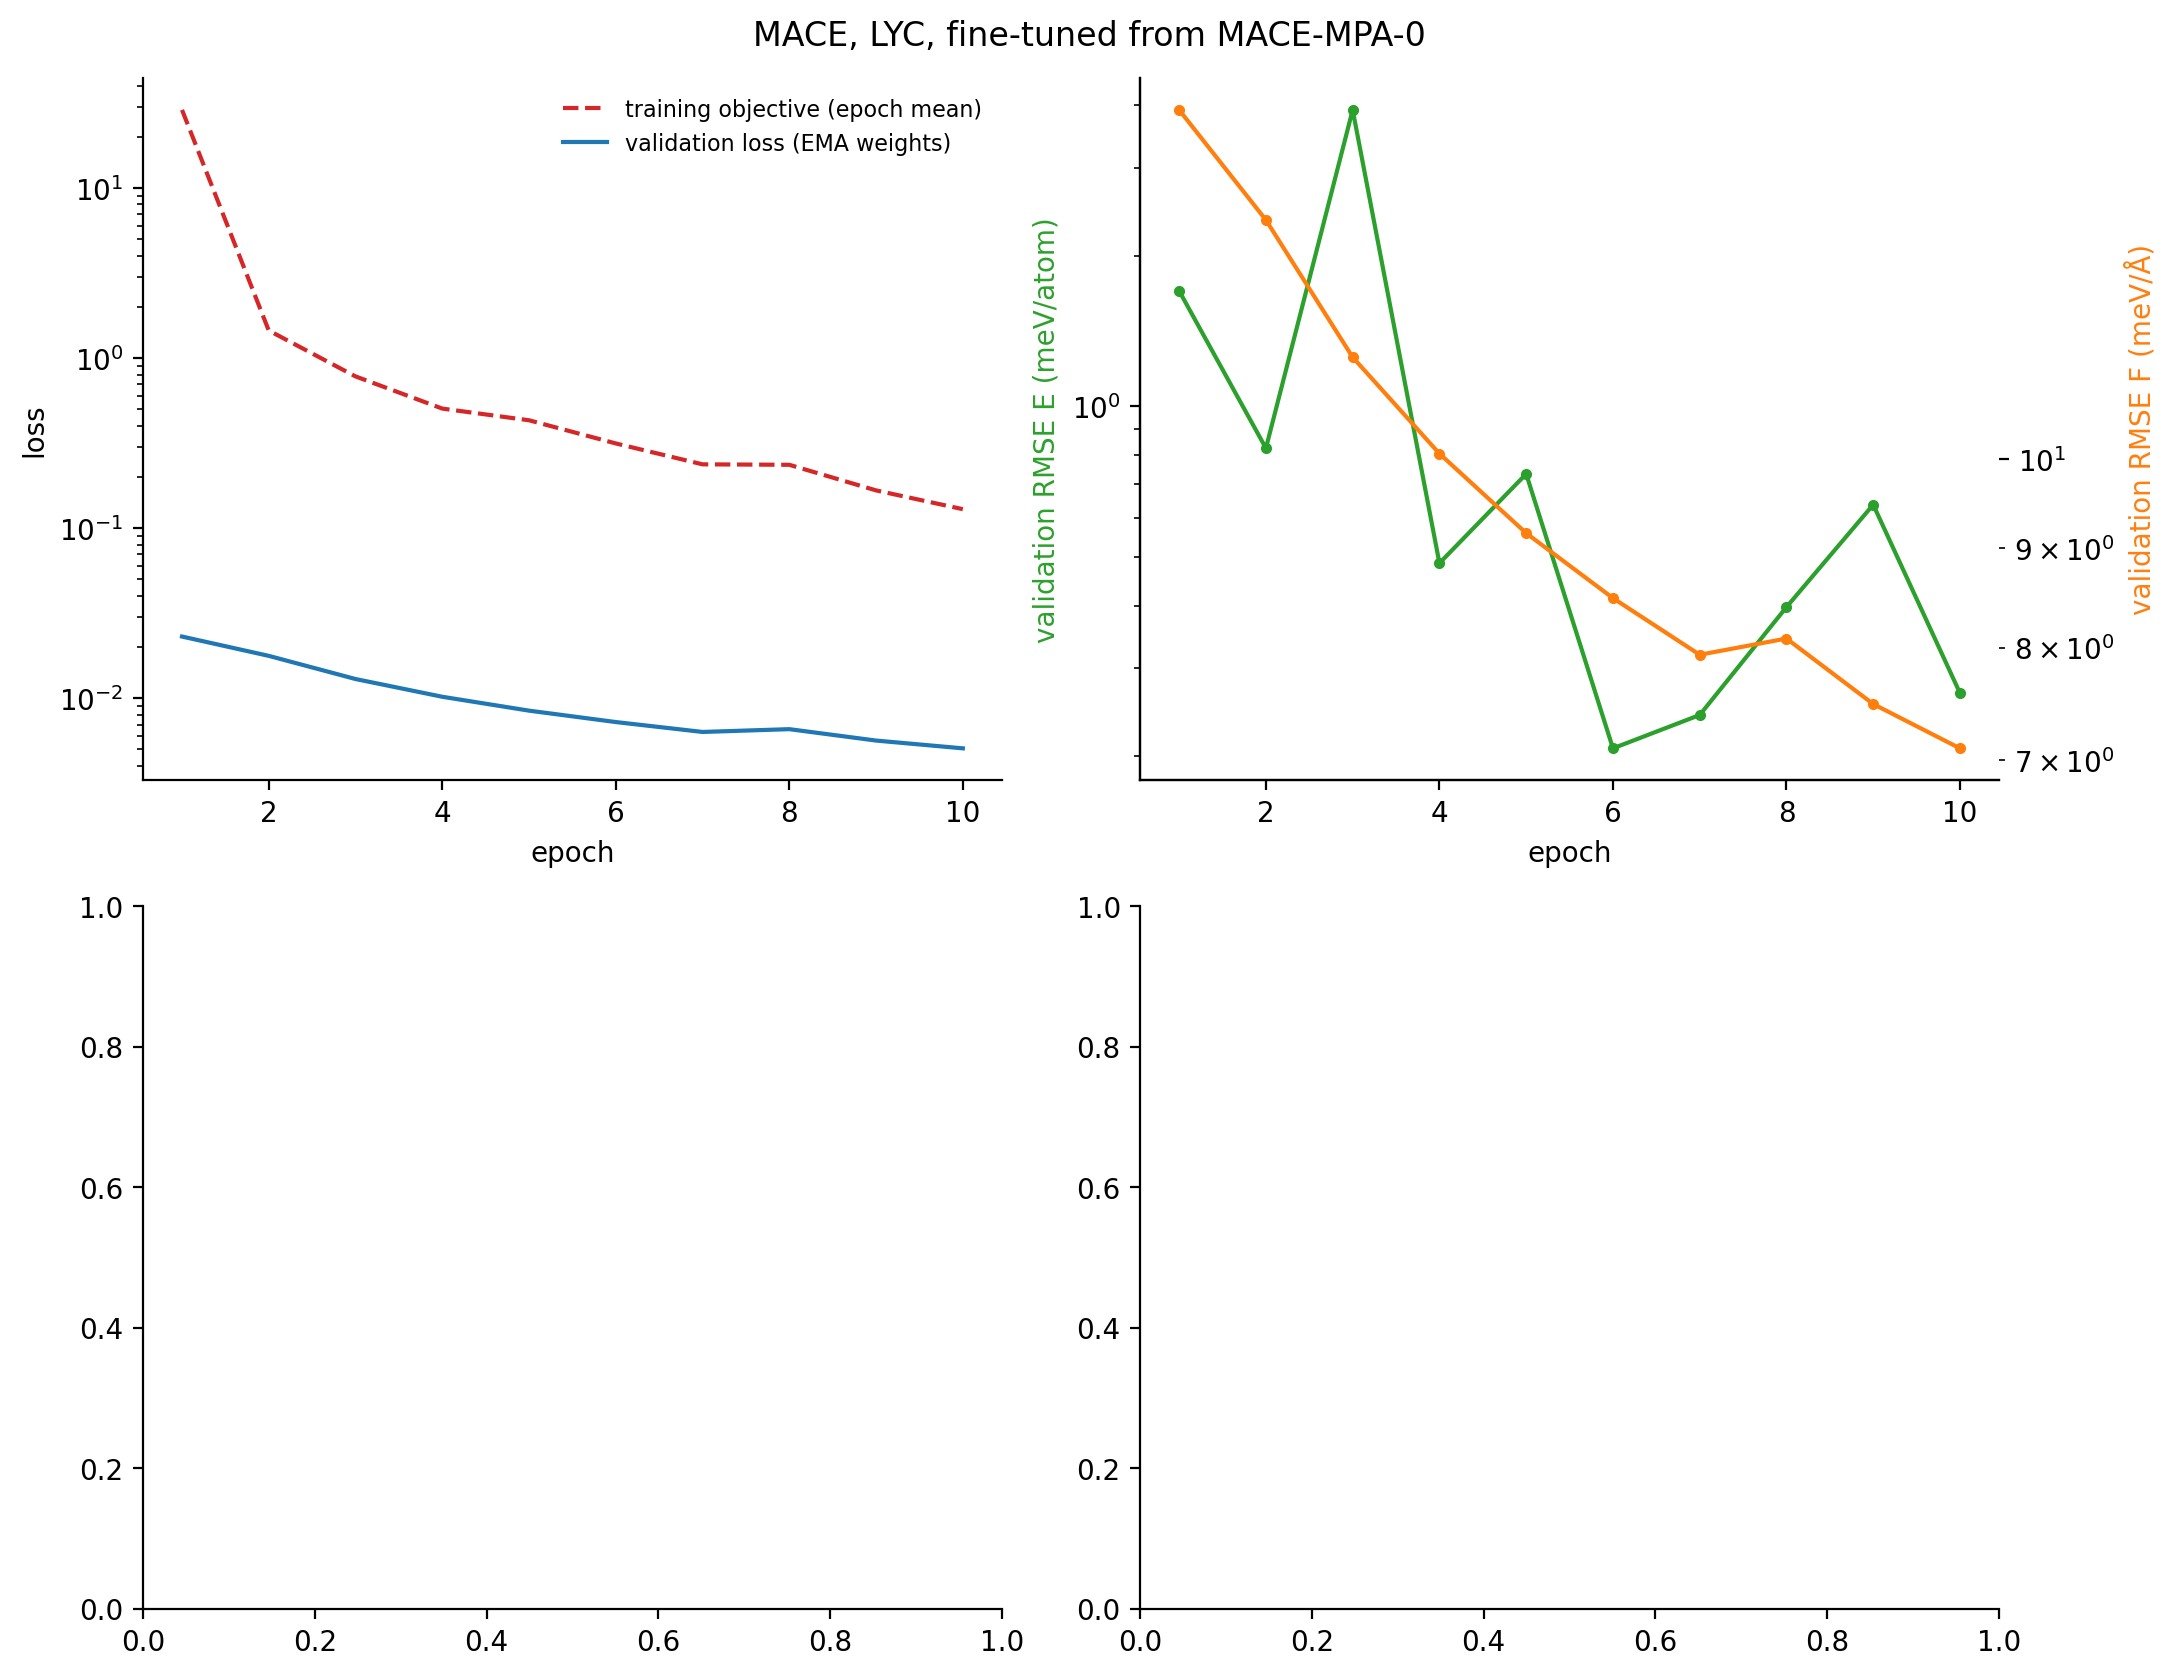

In [9]:
from IPython.display import Image, display
display(Image("../figures/training/parity_mace_lyc_finetuned.png", width=800))

In [10]:
CHG = {"chgnet_lyc_7980_10ep": "first 7,980 frames (900 K block), 10 epochs",
       "chgnet_lyc_7980_200ep": "first 7,980 frames (900 K block), 200 epochs",
       "chgnet_lyc_15960_10ep": "first 15,960 frames (900 K block), 10 epochs",
       "chgnet_lyc_15960_20ep": "first 15,960 frames (900 K block), 20 epochs",
       "chgnet_lyc_30693_10ep": "first 30,693 frames (900 K block), 10 epochs"}
lab = {r["label"]: r for r in runs}
checks = []
for key, label in CHG.items():
    P = load_parity(key); r = lab[label]
    if P is None:
        continue
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
    chgnet_curves(ax[0], r, "f_mae", "C0", "force MAE"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("force MAE (eV/Å)")
    ax[0].legend(["validation", "training (epoch average)"], frameon=False)
    parity(ax[1], P, "energy", 1.0, "eV/atom"); ax[1].set_xlabel("DFT energy (eV/atom)"); ax[1].set_ylabel("CHGNet energy (eV/atom)")
    parity(ax[2], P, "force", 1.0, "eV/Å"); ax[2].set_xlabel("DFT force component (eV/Å)"); ax[2].set_ylabel("CHGNet force component (eV/Å)")
    fig.suptitle(f"CHGNet fine-tuned on LYC: {label}"); fig.tight_layout(); save(fig, f"training/parity_{key}"); plt.close(fig)
    checks.append({"run": key, "log test F MAE (eV/Å)": r["test"]["f_mae"],
                   "recomputed test F MAE (eV/Å)": round(float(np.mean(np.abs(P["test_force_pred"] - P["test_force_ref"]))), 3)})
pd.DataFrame(checks)

,run,log test F MAE (eV/Å),recomputed test F MAE (eV/Å)
0,chgnet_lyc_7980_10ep,0.036,0.035
1,chgnet_lyc_7980_200ep,0.015,0.013
